<a href="https://colab.research.google.com/github/shivani14012004/course-of-python/blob/main/Logistic_Regression_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
path='https://raw.githubusercontent.com/hakimyameen/Datasets/refs/heads/main/heart.csv'

h=pd.read_csv(path)
h[:2]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1


In [3]:
h['target'].value_counts()

,count
target,
1,50490
0,42228


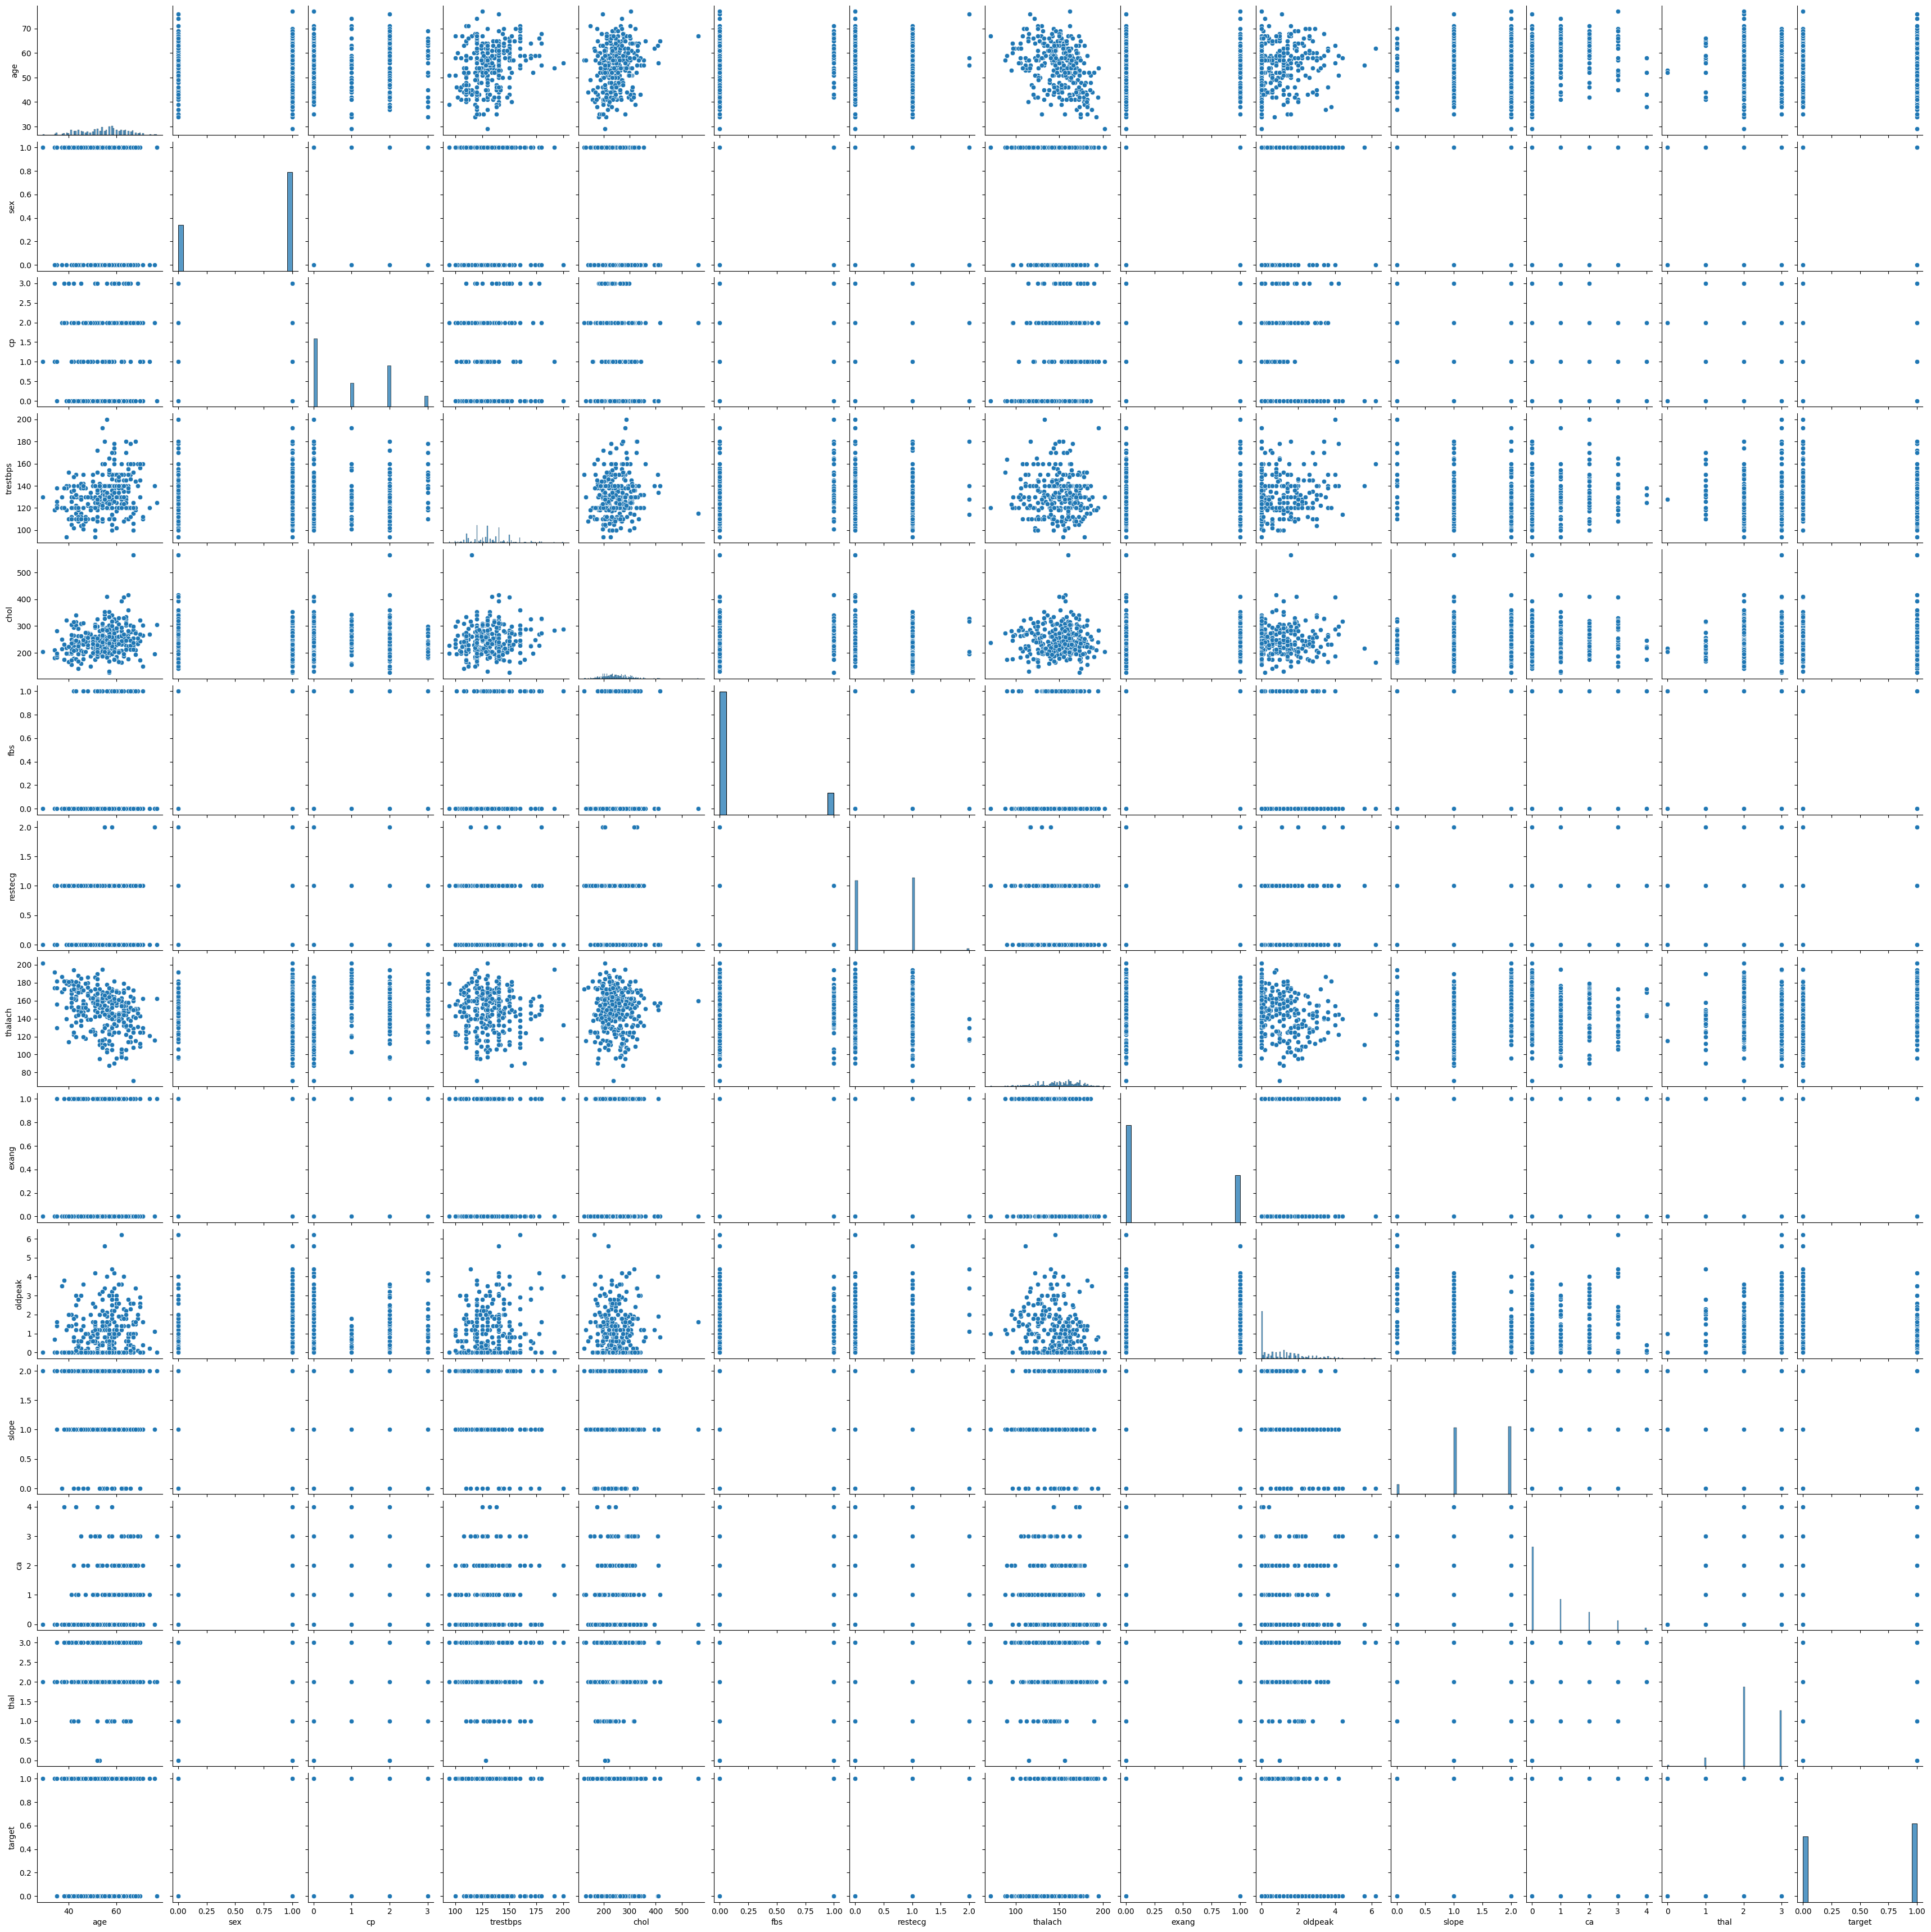

In [3]:
import seaborn as sns
sns.pairplot(data=h)

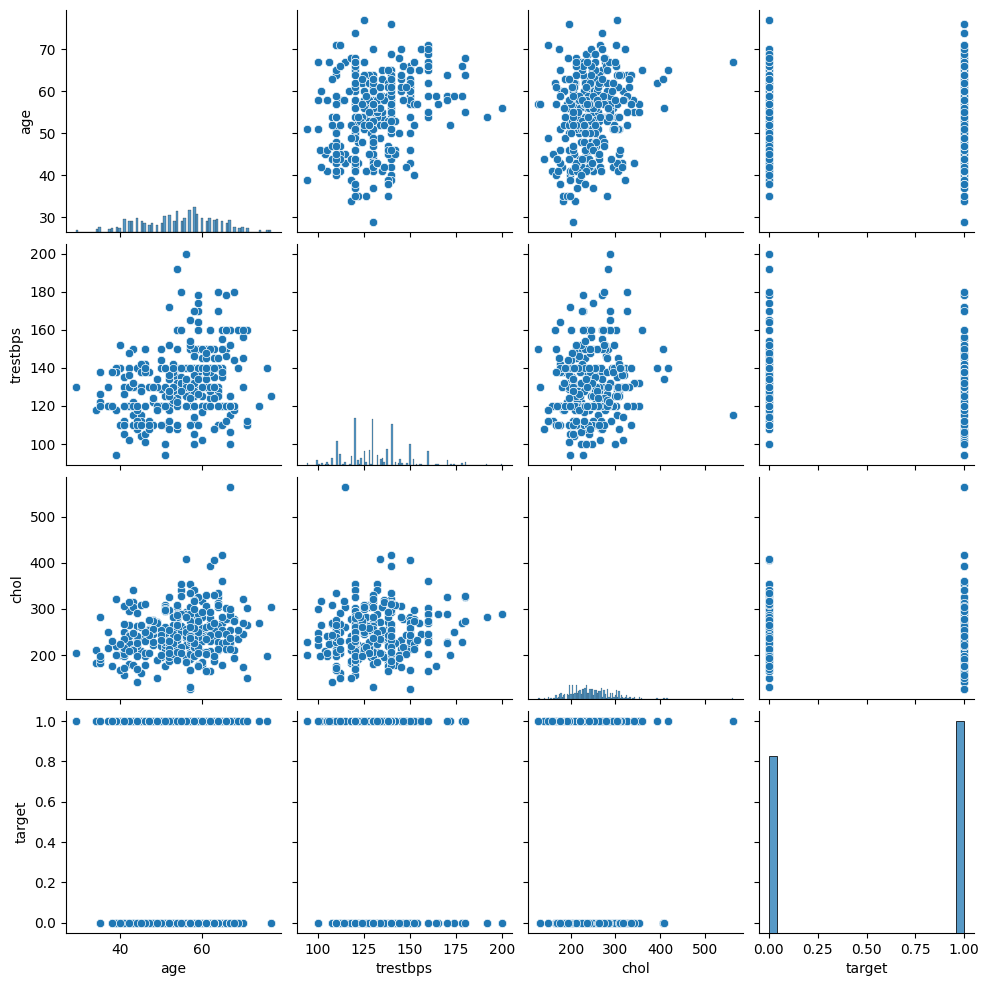

In [4]:
import seaborn as sns
sns.pairplot(data=h[['age','trestbps','chol','target']])

In [4]:
#data prepare
X=h[['age','trestbps','chol']]
y=h['target']

In [6]:
h.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [5]:
#split the dataset
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2)

In [6]:
#Training
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()
model.fit(X_train,y_train)

#Testing
y_pred=model.predict(X_test)

#Check data Score
print('Train Data Score:',model.score(X_train,y_train))
print('Test Data Score:',model.score(X_test,y_test))


Train Data Score: 0.620985790169062
Test Data Score: 0.6183671268334772


In [7]:
X_test[:1]

,age,trestbps,chol
53173,44,120,226


In [8]:
model.predict([[29,130,204]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

In [9]:
sum(y_pred == 0)


np.int64(6947)

Y_pred=1/1+e^(-y)

In [10]:
model.predict_proba([[29,130,204]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.19422803, 0.80577197]])

In [13]:
model.predict_proba([[90,130,204]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.79264751, 0.20735249]])

In [14]:
#         0            1
#array([[0.79126119, 0.20873881]])

#*Performance Metrics for Classification Problem

In [11]:
from sklearn.metrics import confusion_matrix, accuracy_score,precision_score,recall_score,f1_score

In [12]:
#actual output and Predicted output
cm = confusion_matrix(y_test,y_pred)
cm

array([[4186, 4316],
       [2761, 7281]])

<Axes: >

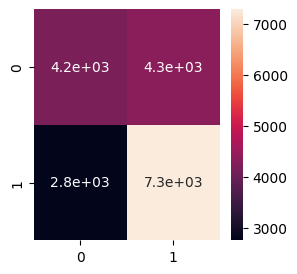

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt #by using matplotlib we reduce size grap
plt.figure(figsize=(3,3))


sns.heatmap(cm,annot=True)


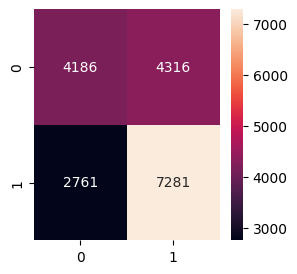

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt #by using matplotlib we reduce size grap
plt.figure(figsize=(3,3))


sns.heatmap(cm,annot=True,fmt='d')
plt.show()

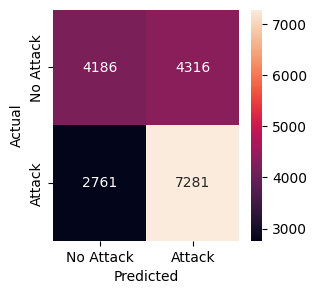

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(3,3))
sns.heatmap(cm,annot=True,fmt='d',xticklabels=['No Attack','Attack'],yticklabels=['No Attack','Attack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [16]:
#accuary TP+TN/Total
len(y_test)

18544

In [17]:
(8956+6547)/18544

0.83601164797239

In [18]:
accuracy_score(y_test,y_pred)*100

61.83671268334771

In [23]:
precision_score(y_test,y_pred)*100

63.47743713399932

In [19]:
recall_score(y_test,y_pred)*100

72.50547699661422

In [20]:
f1_score(y_test,y_pred)*100

67.29516151393318

In [21]:
#everything in one form
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.60      0.49      0.54      8502
           1       0.63      0.73      0.67     10042

    accuracy                           0.62     18544
   macro avg       0.62      0.61      0.61     18544
weighted avg       0.62      0.62      0.61     18544



In [22]:
6547+1856

8403

In [28]:
#Assignment : Check confusion matrix for multilass classifiation
#meaning - i we have more than 2 categories in the predication then how to read confusion matrix
# How you can understand TP,TN,FP,FN

In [24]:
#lets use decision tree algorithm on the same data
from sklearn.tree import DecisionTreeClassifier

In [25]:
dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [26]:
dt_pred = dt.predict(X_test)

In [27]:
dt_pred[:2]

array([1, 1])

In [28]:
print('Traning score:',dt.score(X_train,y_train)*100)
print('Testing score:',dt.score(X_test,y_test)*100)

Traning score: 100.0
Testing score: 100.0


In [29]:
print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8502
           1       1.00      1.00      1.00     10042

    accuracy                           1.00     18544
   macro avg       1.00      1.00      1.00     18544
weighted avg       1.00      1.00      1.00     18544



In [31]:
#Assignment :Test on other algorithms
from sklearn.neighbors import KNeighborsClassifier

In [32]:
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [33]:
knn_pred = knn.predict(X_test)

In [34]:
knn_pred[:2]

array([1, 1])

In [35]:
print('Traning score:',knn.score(X_train,y_train)*100)
print('Testing score:',knn.score(X_test,y_test)*100)

Traning score: 100.0
Testing score: 100.0


In [36]:
print(classification_report(y_test,knn_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8502
           1       1.00      1.00      1.00     10042

    accuracy                           1.00     18544
   macro avg       1.00      1.00      1.00     18544
weighted avg       1.00      1.00      1.00     18544



In [37]:
from sklearn.svm import SVC

In [38]:
sc = SVC()
sc.fit(X_train,y_train)

SVC()

In [39]:
sc_pred = sc.predict(X_test)

In [40]:
sc_pred[:2]

array([1, 0])

In [41]:
print('Traning score:',sc.score(X_train,y_train)*100)
print('Testing score:',sc.score(X_test,y_test)*100)

Traning score: 66.32377922182975
Testing score: 66.38805004314064


In [42]:
print(classification_report(y_test,sc_pred))

              precision    recall  f1-score   support

           0       0.66      0.55      0.60      8502
           1       0.67      0.76      0.71     10042

    accuracy                           0.66     18544
   macro avg       0.66      0.66      0.66     18544
weighted avg       0.66      0.66      0.66     18544



In [44]:
from sklearn.naive_bayes import GaussianNB

In [45]:
gb = GaussianNB()
gb.fit(X_train,y_train)

GaussianNB()

In [46]:
gb_pred = gb.predict(X_test)

In [47]:
gb_pred[:2]

array([1, 1])

In [48]:
print('Traning score:',gb.score(X_train,y_train)*100)
print('Testing score:',gb.score(X_test,y_test)*100)

Traning score: 61.88287000835872
Testing score: 62.6995254529767


In [49]:
print(classification_report(y_test,gb_pred))

              precision    recall  f1-score   support

           0       0.61      0.52      0.56      8506
           1       0.64      0.72      0.68     10038

    accuracy                           0.63     18544
   macro avg       0.62      0.62      0.62     18544
weighted avg       0.63      0.63      0.62     18544



In [50]:
from sklearn.ensemble import RandomForestClassifier

In [52]:
rf = RandomForestClassifier()
rf.fit(X_train,y_train)

RandomForestClassifier()

In [53]:
rf_pred = rf.predict(X_test)

In [54]:
rf_pred[:2]

array([1, 0])

In [55]:
print('Traning score:',rf.score(X_train,y_train)*100)
print('Testing score:',rf.score(X_test,y_test)*100)

Traning score: 100.0
Testing score: 100.0


In [56]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8506
           1       1.00      1.00      1.00     10038

    accuracy                           1.00     18544
   macro avg       1.00      1.00      1.00     18544
weighted avg       1.00      1.00      1.00     18544



In [ ]:
#Practice

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2)

In [ ]:
#Training
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()
model.fit(X_train,y_train)



In [ ]:
#Testing
y_pred=model.predict(X_test)

In [ ]:
#Check data Score
print('Train Data Score:',model.score(X_train,y_train))
print('Test Data Score:',model.score(X_test,y_test))

In [ ]:
X_test[:1]

In [ ]:
model.predict([[45,1,145,204,150]])

In [ ]:
# Y_pred=1/1+e^(-y)
model.predict_proba([[45,1,145,204,150]])

In [ ]:
#data prepare
X=h[['cp','trestbps','chol','thalach','oldpeak']]
y=h['target']

In [ ]:
#split the dataset
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2)

In [ ]:
#Training
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()
model.fit(X_train,y_train)

#Testing
y_pred=model.predict(X_test)

#Check data Score
print('Train Data Score:',model.score(X_train,y_train))
print('Test Data Score:',model.score(X_test,y_test))

In [ ]:
#data prepare
X=h[['sex','cp','trestbps','chol','thalach','oldpeak']]
y=h['target']

In [ ]:
#split the dataset
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2)

In [ ]:
#Training
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()
model.fit(X_train,y_train)

#Testing
y_pred=model.predict(X_test)

#Check data Score
print('Train Data Score:',model.score(X_train,y_train))
print('Test Data Score:',model.score(X_test,y_test))

In [ ]:
#data prepare
X=h[['sex','cp','trestbps','chol','thalach','ca','thal']]
y=h['target']

In [ ]:
#split the dataset
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2)

In [ ]:
#Training
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()
model.fit(X_train,y_train)

#Testing
y_pred=model.predict(X_test)

#Check data Score
print('Train Data Score:',model.score(X_train,y_train))
print('Test Data Score:',model.score(X_test,y_test))